In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score

import warnings
warnings.filterwarnings('ignore')


In [56]:
df = pd.read_csv('HR_comma_sep.csv')

In [57]:
#1. Perform data quality checks by checking for missing values, if any.

In [58]:
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [59]:
# Fixing - "average_montly_hours" to "average_monthly_hours"

df = df.rename(columns = {'average_montly_hours': 'average_monthly_hours'})


In [60]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_monthly_hours  14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [62]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [63]:
## Findings - I have checked the data for all the null values and the data was free from it. So we can use the data as it is.

#2.Understand what factors contributed most to employee turnover at EDA.

2.1.Draw a heatmap of the correlation matrix between all numerical features or columns in the data.

2.2.Draw the distribution plot of:
■ Employee Satisfaction (use column satisfaction_level)
■ Employee Evaluation (use column last_evaluation)
■ Employee Average Monthly Hours (use column average_montly_hours)

2.3.Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.

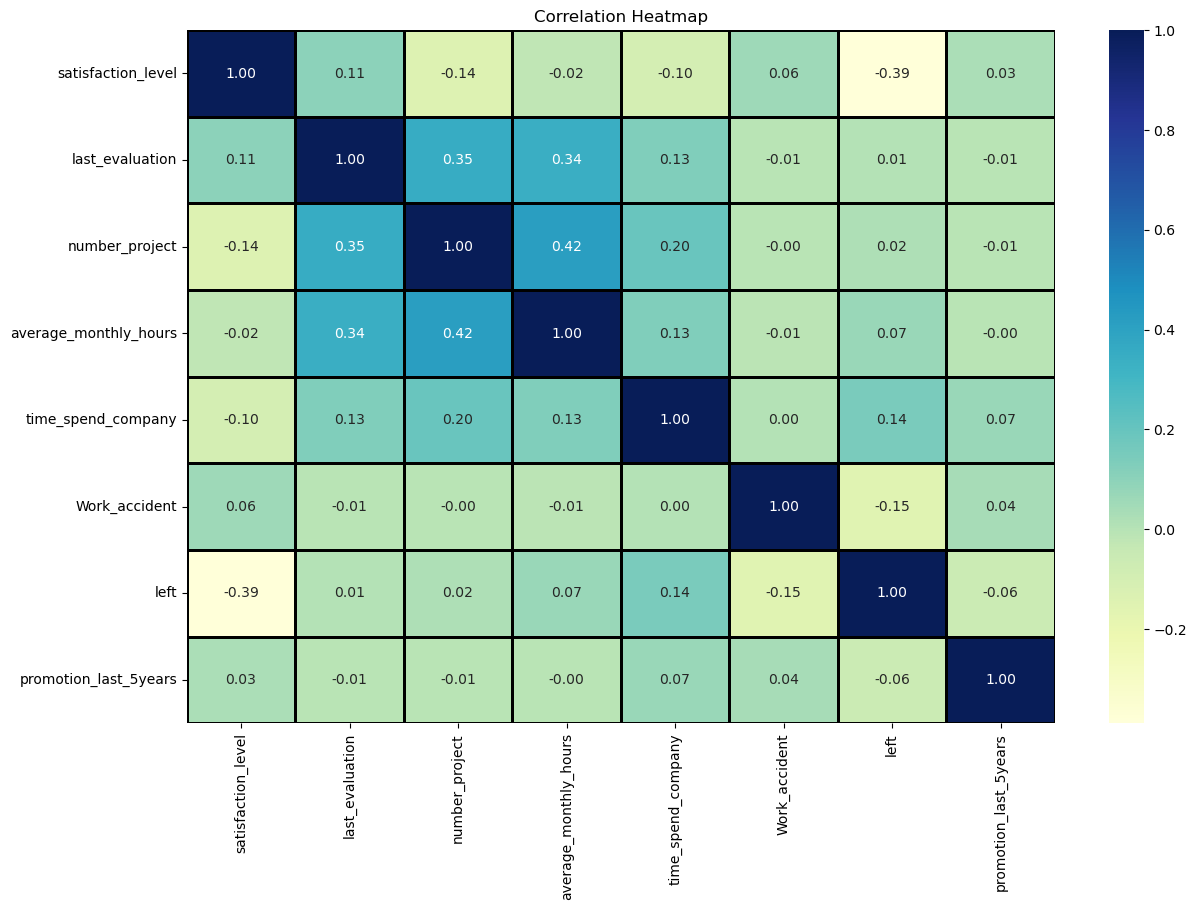

In [64]:
# Select Only Numeric Columns

numeric_cols = df.select_dtypes(include = 'number')

# Compute Correlation Matrix

corr_matrix = numeric_cols.corr()

# Heatmap Plotting

plt.figure(figsize = (14, 9))
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = 'YlGnBu'  , linewidths = 0.8 , linecolor = 'black')
plt.title('Correlation Heatmap')
plt.show()


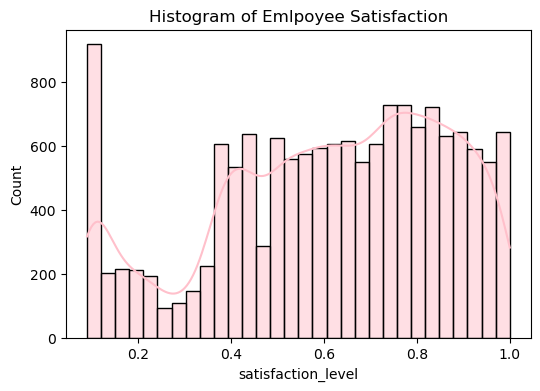

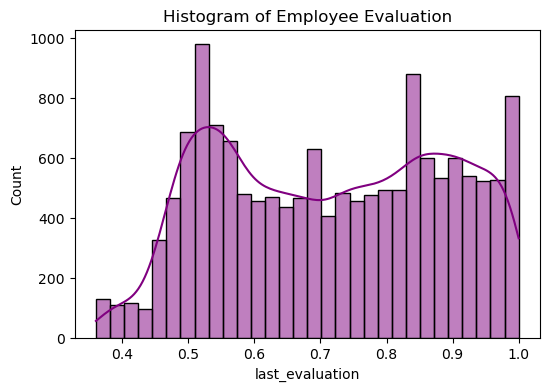

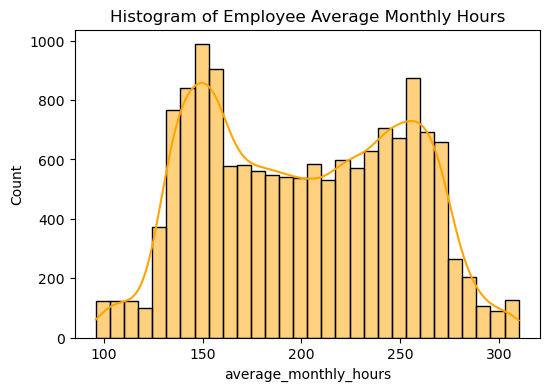

In [65]:
# Histograms

plt.figure(figsize = (6, 4))
sns.histplot(df['satisfaction_level'], kde = True, bins = 30, color = 'pink')
plt.title(f'Histogram of Emlpoyee Satisfaction')

plt.figure(figsize = (6, 4))
sns.histplot(df['last_evaluation'], kde = True, bins = 30, color = 'purple')
plt.title(f'Histogram of Employee Evaluation')

plt.figure(figsize = (6, 4))
sns.histplot(df['average_monthly_hours'], kde = True, bins = 30, color = 'orange')
plt.title(f'Histogram of Employee Average Monthly Hours')

plt.show()

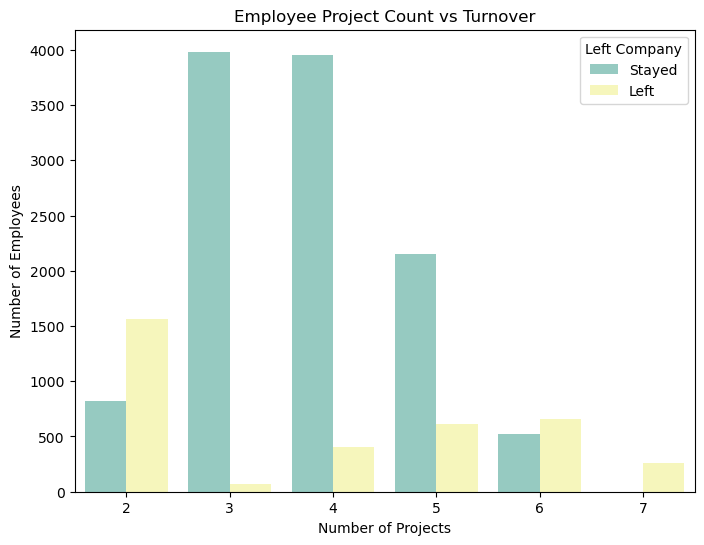

In [66]:
# Bar Plot of Number of Projects vs. Employee Turnover

plt.figure(figsize = (8, 6))
sns.countplot(data = df, x = 'number_project', hue = 'left', palette = 'Set3')

plt.title('Employee Project Count vs Turnover')
plt.xlabel('Number of Projects')
plt.ylabel('Number of Employees')
plt.legend(title = 'Left Company', labels = ['Stayed', 'Left'])
plt.show()

In [67]:
# Inference - The graph suggests that a moderate number of projects (3-4) is associated with higher employee retention, while having too few (2) or too many (5-7) projects may contribute to a higher likelihood of employees leaving the company.

3.Perform clustering of employees who left based on their satisfaction and evaluation.

3.1. Choose columns satisfaction_level, last_evaluation, and left.

3.2. Do K-means clustering of employees who left the company into 3 clusters.

3.3. Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.

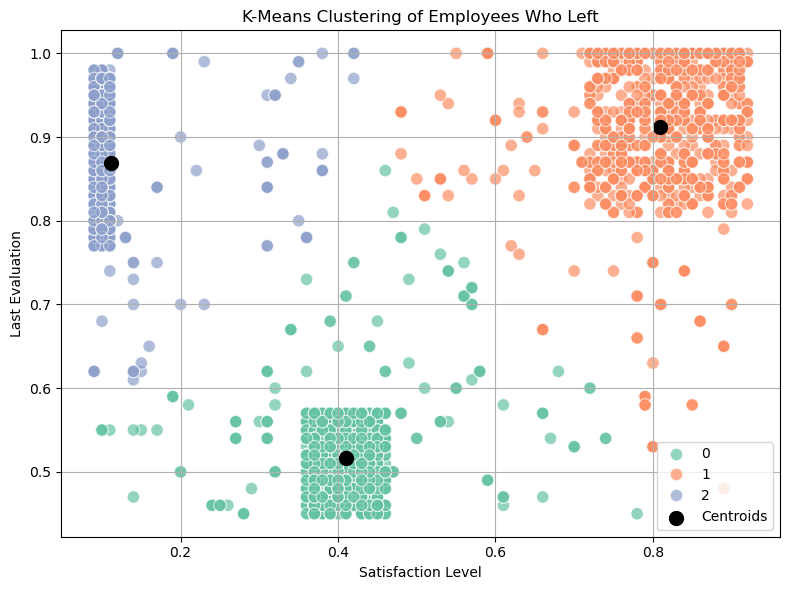

In [68]:
# Filter Employees Who Left

df_left = df[df['left'] == 1][['satisfaction_level', 'last_evaluation']]

# Apply K-Means Wth 3 Clusters

kmeans = KMeans(n_clusters = 3, random_state = 42)
df_left['cluster'] = kmeans.fit_predict(df_left)

# View Cluster Centers

centers = kmeans.cluster_centers_

# Plotting The Clusters

plt.figure(figsize = (8, 6))
sns.scatterplot(
    x = 'satisfaction_level',
    y = 'last_evaluation',
    hue = 'cluster',
    data = df_left,
    palette = 'Set2',
    s = 80,
    alpha = 0.7
)
plt.scatter(centers[:, 0], centers[:, 1], c = 'black', s = 100, marker = 'o', label = 'Centroids')
plt.title('K-Means Clustering of Employees Who Left')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


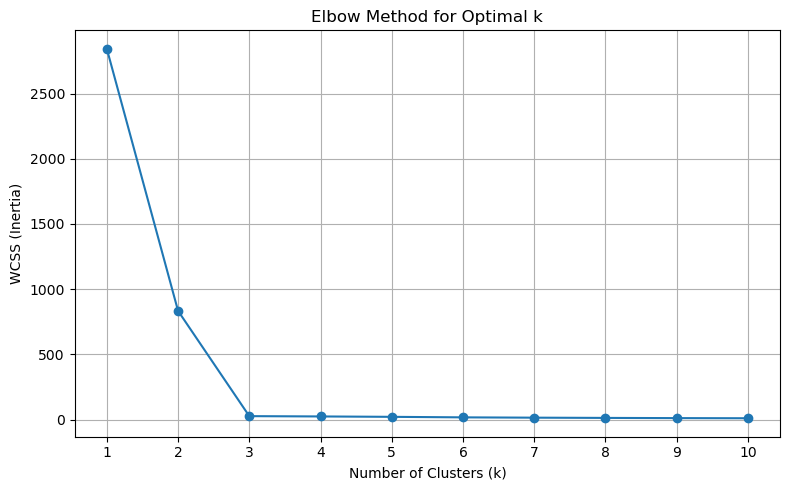

In [69]:
# Elbow Method: Calculate WCSS(Within-Cluster Sum of Squares) for k = 1 to 10

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(df_left)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve

plt.figure(figsize = (8, 5))
plt.plot(k_range, wcss, marker = 'o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()


Silhouette Score for k=2: 0.7058
Silhouette Score for k=3: 0.9164
Silhouette Score for k=4: 0.6448
Silhouette Score for k=5: 0.5365


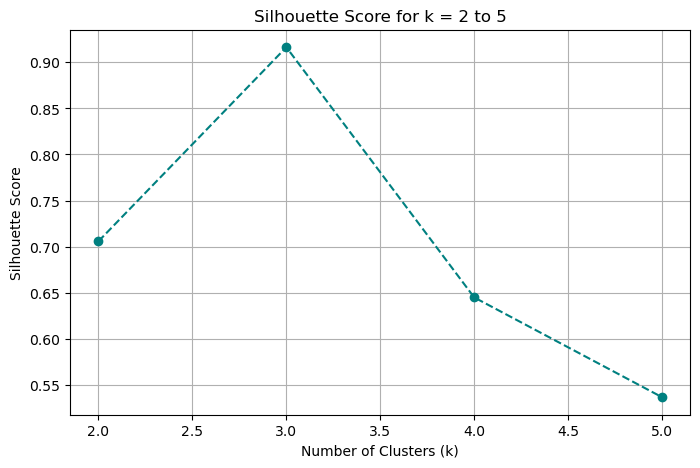

In [70]:
# Store Silhouette Scores

sil_scores = []
k_values = range(2, 6)

for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(df_left)
    score = silhouette_score(df_left, labels)
    sil_scores.append(score)
    print(f"Silhouette Score for k={k}: {score:.4f}")

# Plotting Scores

plt.figure(figsize = (8, 5))
plt.plot(k_values, sil_scores, marker = 'o', linestyle = '--', color = 'teal')
plt.title('Silhouette Score for k = 2 to 5')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()


# Findings - k with the highest silhouette score indicates the most well-defined cluster separation.

Here k = 3 has the highest score so it supports your earlier clustering into 3 groups.

4. Handle the left Class Imbalance using the SMOTE technique.

4.1. Pre-process the data by converting categorical columns to numerical columns by:
■ Separating categorical variables and numeric variables
■ Applying get_dummies() to the categorical variables
■ Combining categorical variables and numeric variables

4.2. Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.

4.3. Upsample the train dataset using the SMOTE technique from the imblearn module.

In [71]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [72]:
class_distribution = df['left'].value_counts()
print(class_distribution)

left
0    11428
1     3571
Name: count, dtype: int64


In [73]:
# Separate Features and Target

X = df.drop("left", axis=1)
y = df["left"]

# Separate Categorical and Numerical Columns

categorical_cols = X.select_dtypes(include = ['object', 'category']).columns
numeric_cols = X.select_dtypes(include = ['int64', 'float64']).columns

# Apply Get_Dummies to Categorical Variables

X_categorical_encoded = pd.get_dummies(X[categorical_cols], drop_first = True)

# Combine Numerical and Encoded Categorical Variables

X_processed = pd.concat([X[numeric_cols], X_categorical_encoded], axis = 1)


# Apply SMOTE

smote = SMOTE(random_state = 42)
X_resampled, y_resampled = smote.fit_resample(X_processed, y)

# Check the New Class Distribution

from collections import Counter

print("Before SMOTE:", Counter(y))
print("After SMOTE:", Counter(y_resampled))


Before SMOTE: Counter({0: 11428, 1: 3571})
After SMOTE: Counter({1: 11428, 0: 11428})


In [74]:
# Perform a 80:20 Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, 
    test_size = 0.2, 
    random_state = 123
)

# SMOTE on Training Data

smote = SMOTE(random_state = 123)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_resampled))


Before SMOTE: Counter({0: 9137, 1: 2862})
After SMOTE: Counter({0: 9137, 1: 9137})


# 5. Perform 5-fold cross-validation model training and evaluate performance.

5.1. Train a logistic regression model, apply a 5-fold CV, and plot the classification report.
5.2. Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.
5.3. Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.


In [75]:
# Model Cross Validation, Training and Evaluation

def evaluate_model_with_cv(model, X, y, model_name):

    y_pred = cross_val_predict(model, X, y, cv = 5)

    print(f"\nClassification Report for {model_name}:\n")
    report = classification_report(y, y_pred, output_dict = True)
    print(classification_report(y, y_pred))

    # Heatmap of Classification Report
    
    plt.figure(figsize = (8, 4))
    sns.heatmap(
        pd.DataFrame(report).iloc[:-1, :].T,
        annot = True, cmap = 'Greens', fmt = '.2f'
    )
    plt.title(f'{model_name} - Classification Report (5-Fold CV)')
    plt.show()



Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.81      0.77      0.79      9137
           1       0.78      0.82      0.80      9137

    accuracy                           0.80     18274
   macro avg       0.80      0.80      0.80     18274
weighted avg       0.80      0.80      0.80     18274



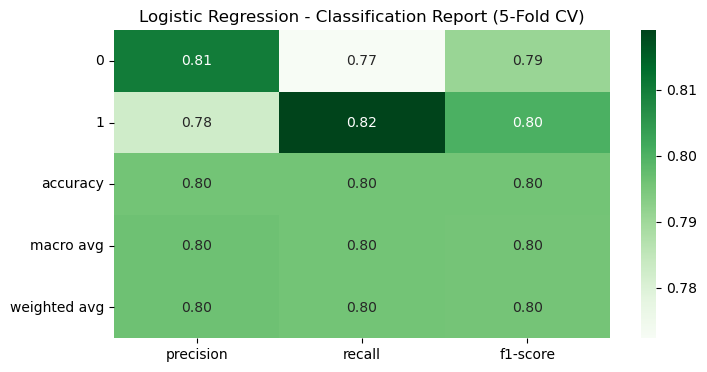

In [76]:
# Logistic Regression

log_reg = LogisticRegression(max_iter = 1000, random_state = 123)
evaluate_model_with_cv(log_reg, X_train_resampled, y_train_resampled, "Logistic Regression")



Classification Report for Random Forest Classifier:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      9137
           1       0.99      0.97      0.98      9137

    accuracy                           0.98     18274
   macro avg       0.98      0.98      0.98     18274
weighted avg       0.98      0.98      0.98     18274



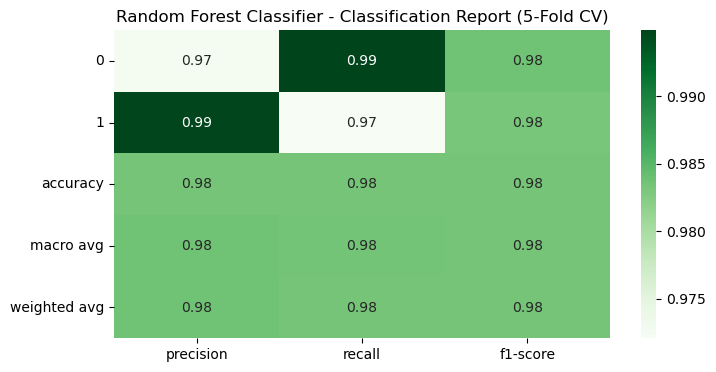

In [77]:
# Random Forest

rf_clf = RandomForestClassifier(n_estimators = 100, random_state = 123)
evaluate_model_with_cv(rf_clf, X_train_resampled, y_train_resampled, "Random Forest Classifier")


In [ ]:
# Gradient Boosting

gb_clf = GradientBoostingClassifier(n_estimators = 100, learning_rate = 0.1, random_state = 123)
evaluate_model_with_cv(gb_clf, X_train_resampled, y_train_resampled, "Gradient Boosting Classifier")


# 6.Identify the best model and justify the evaluation metrics used.

6.1. Find the ROC/AUC for each model and plot the ROC curve.
6.2. Find the confusion matrix for each of the models.
6.3. Explain which metric needs to be used from the confusion matrix: Recall or Precision?


In [ ]:
# Dictionary to Store AUC Scores

auc_scores = {}

# Plotting

plt.figure(figsize = (10, 6))
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    auc_scores[name] = roc_auc
    plt.plot(fpr, tpr, label = f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc = 'lower right')
plt.grid(True)
plt.show()


In [ ]:
# Confusion Matrix

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix for {name}:\n{cm}")
    disp = ConfusionMatrixDisplay(confusion_matrix = cm)
    disp.plot(cmap = 'Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()


In [ ]:
# Dictionaries to Store Metrics

precision_scores = {}
recall_scores = {}

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    precision_scores[name] = precision
    recall_scores[name] = recall

print("Model Performance (Precision & Recall):\n")
for model_name in models.keys():
    print(f"{model_name}:")
    print(f"  Precision: {precision_scores[model_name]:.4f}")
    print(f"     Recall: {recall_scores[model_name]:.4f}\n")


# Interpretation :

Logistic Regression: Higher Recall, but lower Precision → more false positives.

Random Forest: Balanced Precision and Recall.

Gradient Boosting: Best trade-off — high Precision and Recall.

# Conclusion :
    
Use Recall if false negatives are costly (e.g., fraud, disease detection).

Best model overall based on both Precision and Recallis Gradient Boosting Classifier.

# 7. Suggest various retention strategies for targeted employees.

7.1. Using the best model, predict the probability of employee turnover in the test data.

7.2. Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.
■	Safe Zone (Green) (Score < 20%)
■	Low-Risk Zone (Yellow) (20% < Score < 60%)
■	Medium-Risk Zone (Orange) (60% < Score < 90%)
■	High-Risk Zone (Red) (Score > 90%).


In [ ]:
# Predict Probability of Employee Turnover

y_proba = models["Gradient Boosting"].predict_proba(X_test)[:, 1]

# Converting into DataFrame

predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Turnover_Probability': y_proba
})

predictions_df.head()


In [ ]:
def classify_zone(prob):
    if prob < 0.20:
        return 'Safe Zone (Green)'
    elif prob < 0.60:
        return 'Low-Risk Zone (Yellow)'
    elif prob < 0.90:
        return 'Medium-Risk Zone (Orange)'
    else:
        return 'High-Risk Zone (Red)'

# Apply Classification

predictions_df['Risk_Zone'] = predictions_df['Turnover_Probability'].apply(classify_zone)

predictions_df.head()


In [ ]:
# Zone Prediction

zone_counts = predictions_df['Risk_Zone'].value_counts()
print(zone_counts)


In [ ]:
# Suggestions On Retention Strategies by Risk Zone

1. Safe Zone (Green)
(Score < 20%) Employees highly likely to stay-
- Recognize their loyalty
- Encourage them to mentor others
- Offer performance incentives
    
2. Low-Risk Zone (Yellow)
(20%–60%) Mild chance of turnover-
- Monitor job satisfaction
- Offer career development programs
- Regular feedback sessions
 
3. Medium-Risk Zone (Orange)
(60%–90%) High chance of leaving soon-
- Conduct 1:1 retention interviews
- Offer competitive benefits
- Reduce workload stress
- Assign meaningful projects

4. High-Risk Zone (Red)
(>90%) Critical risk of resignation-
- Immediate intervention (HR + Manager)
- Personalized career paths
- Salary adjustments or bonuses
- Address grievances promptly